In [1]:
# ONLY RUN THIS IF YOU'RE IN GOOGLE COLAB
from google.colab import drive
import os

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Thesis/Pintu-Air')

# Verify you're in the right place
!pwd
!ls -la

Mounted at /content/drive
/content/drive/MyDrive/Thesis/Pintu-Air
total 24843
-rw------- 1 root root 5517847 Jun 11 14:58 '01 Result Data Cleaning Part 1.csv'
-rw------- 1 root root 1964974 Jun 11 14:58 '02 Data Preperation.ipynb'
-rw------- 1 root root  256098 Jun 11 14:58 '02 X_test.csv'
-rw------- 1 root root 4831129 Jun 11 14:58 '02 X_train.csv'
-rw------- 1 root root   40580 Jun 11 14:58 '02 y_test.csv'
-rw------- 1 root root  770651 Jun 11 14:58 '02 y_train.csv'
-rw------- 1 root root  322748 Jun 11 14:58 '03 ARIMA.ipynb'
-rw------- 1 root root    2277 Jun 11 14:58  03_Result_ARIMA.csv
-rw------- 1 root root 6247212 Jun 11 14:58  04c_ARIMA_Manggarai.ipynb
-rw------- 1 root root  631448 Jun 11 14:58  06_DataPreperation_ML.ipynb
-rw------- 1 root root 1611961 Jun 11 14:58  07a_best_model.keras
-rw------- 1 root root  371715 Jun 11 14:58  07a_LSTM_Manggarai.ipynb
-rw------- 1 root root 1685693 Jun 11 14:58  07b_best_model.keras
-rw------- 1 root root  368771 Jun 11 14:58  07b_LSTM_M

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import shap
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set style and random seed
plt.style.use('default')
np.random.seed(42)

In [4]:
X_train = pd.read_csv('06_X_train_significant.csv', index_col='Tanggal', parse_dates=True)
X_test = pd.read_csv('06_X_test_significant.csv', index_col='Tanggal', parse_dates=True)
y_train = pd.read_csv('04_y_train.csv', index_col='Tanggal', parse_dates=True).squeeze()
y_test = pd.read_csv('04_y_test.csv', index_col='Tanggal', parse_dates=True).squeeze()

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\ny_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nFeatures: {list(X_train.columns)}")


X_train shape: (33972, 57)
X_test shape: (1788, 57)

y_train shape: (33972,)
y_test shape: (1788,)

Features: ['time_index', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos', 'manggarai_air_lag1', 'manggarai_air_lag2', 'manggarai_air_lag3', 'manggarai_air_lag4', 'manggarai_air_lag5', 'manggarai_air_lag6', 'manggarai_air_lag7', 'manggarai_air_lag9', 'manggarai_air_lag12', 'manggarai_air_lag14', 'manggarai_air_lag15', 'manggarai_air_lag17', 'manggarai_air_lag20', 'manggarai_air_lag21', 'depok_air_lag3', 'depok_air_lag6', 'depok_air_lag7', 'depok_air_lag8', 'depok_air_lag9', 'depok_air_lag10', 'depok_air_lag12', 'depok_air_lag13', 'depok_air_lag14', 'depok_air_lag16', 'depok_air_lag19', 'depok_air_lag20', 'depok_air_lag23', 'depok_air_lag24', 'katulampa_air_lag3', 'katulampa_air_lag4', 'katulampa_air_lag5', 'katulampa_air_lag14', 'katulampa_air_lag19', 'katulampa_air_lag21', 'manggarai_cuaca_lag1_hujan', 'manggarai_cuaca_lag2_hujan', 'manggarai_cuaca_lag4_hujan', 'manggarai_cuaca

# Baseline Model

In [4]:
fixed_params = {
    'tree_method': 'gpu_hist',
    'gpu_id': 0,
    'objective': 'reg:squarederror',
    'n_jobs': -1,
    'random_state': 42,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

results = []


start_time = datetime.now()

# Train Baseline
model_base = xgb.XGBRegressor(**fixed_params)
model_base.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

training_time = datetime.now() - start_time
training_time_sec = training_time.total_seconds() 

# Hitung Metrik Baseline
base_train_pred = model_base.predict(X_train)
base_test_pred = model_base.predict(X_test)

b_tr_rmse = np.sqrt(mean_squared_error(y_train, base_train_pred))
b_tr_mae = mean_absolute_error(y_train, base_train_pred)
b_tr_mape = mean_absolute_percentage_error(y_train, base_train_pred)
b_tr_r2 = r2_score(y_train, base_train_pred)

b_te_rmse = np.sqrt(mean_squared_error(y_test, base_test_pred))
b_te_mae = mean_absolute_error(y_test, base_test_pred)
b_te_mape = mean_absolute_percentage_error(y_test, base_test_pred)
b_te_r2 = r2_score(y_test, base_test_pred)

# Simpan Baseline
results.append({
    'learning_rate': 'BASELINE',
    'n_estimators': 'BASELINE',
    'max_depth': 'BASELINE',
    
    # Masukkan Waktu Training
    'training_time_sec': round(training_time_sec, 4),
    
    'train_rmse': round(b_tr_rmse, 8),
    'train_mae': round(b_tr_mae, 8),
    'train_mape': round(b_tr_mape, 8),
    'train_r2': round(b_tr_r2, 8),
    'test_rmse': round(b_te_rmse, 8),
    'test_mae': round(b_te_mae, 8),
    'test_mape': round(b_te_mape, 8),
    'test_r2': round(b_te_r2, 8)
})

In [5]:
results

[{'learning_rate': 'BASELINE',
  'n_estimators': 'BASELINE',
  'max_depth': 'BASELINE',
  'training_time_sec': 3.9643,
  'train_rmse': np.float64(8.53243647),
  'train_mae': 2.93847906,
  'train_mape': 0.00739906,
  'train_r2': 0.9630002,
  'test_rmse': np.float64(30.89913386),
  'test_mae': 12.11296547,
  'test_mape': 0.02144645,
  'test_r2': -2.06982222}]

# Hyperparameter Tuning

In [6]:
# Parameter yang akan diubah-ubah (Grid)
param_learning_rate = [0.05, 0.1, 0.2]
param_n_estimators = [30]
param_max_depth = [6, 7, 8]

In [7]:
len(param_learning_rate) * len(param_n_estimators) * len(param_max_depth)

9

In [8]:
total_combinations = len(param_learning_rate) * len(param_n_estimators) * len(param_max_depth)
counter = 0

for lr in param_learning_rate:
    for n_est in param_n_estimators:
        for depth in param_max_depth:
            counter += 1
            
            # Gabungkan parameter fixed dengan parameter loop saat ini
            current_params = fixed_params.copy()
            current_params['learning_rate'] = lr
            current_params['n_estimators'] = n_est
            current_params['max_depth'] = depth
            
            print(f"[{counter}/{total_combinations}] Training: lr={lr}, n_est={n_est}, depth={depth}")
            
            # --- Mulai Timer Loop ---
            loop_start_time = datetime.now()
            
            # Train Model
            model = xgb.XGBRegressor(**current_params)
            model.fit(
                X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False
            )
            
            # --- Stop Timer Loop ---
            loop_training_time = datetime.now() - loop_start_time
            loop_time_sec = loop_training_time.total_seconds()
            
            # Predict
            train_pred = model.predict(X_train)
            test_pred = model.predict(X_test)
            
            # Calculate Metrics (Train)
            tr_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
            tr_mae = mean_absolute_error(y_train, train_pred)
            tr_mape = mean_absolute_percentage_error(y_train, train_pred)
            tr_r2 = r2_score(y_train, train_pred)
            
            # Calculate Metrics (Test)
            te_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
            te_mae = mean_absolute_error(y_test, test_pred)
            te_mape = mean_absolute_percentage_error(y_test, test_pred)
            te_r2 = r2_score(y_test, test_pred)
            
            # Append to results
            results.append({
                'learning_rate': lr,
                'n_estimators': n_est,
                'max_depth': depth,
                
                # Masukkan Waktu Training
                'training_time_sec': round(loop_time_sec, 4),
                
                'train_rmse': round(tr_rmse, 8),
                'train_mae': round(tr_mae, 8),
                'train_mape': round(tr_mape, 8),
                'train_r2': round(tr_r2, 8),
                'test_rmse': round(te_rmse, 8),
                'test_mae': round(te_mae, 8),
                'test_mape': round(te_mape, 8),
                'test_r2': round(te_r2, 8)
            })

[1/9] Training: lr=0.05, n_est=30, depth=6
[2/9] Training: lr=0.05, n_est=30, depth=7
[3/9] Training: lr=0.05, n_est=30, depth=8
[4/9] Training: lr=0.1, n_est=30, depth=6
[5/9] Training: lr=0.1, n_est=30, depth=7
[6/9] Training: lr=0.1, n_est=30, depth=8
[7/9] Training: lr=0.2, n_est=30, depth=6
[8/9] Training: lr=0.2, n_est=30, depth=7
[9/9] Training: lr=0.2, n_est=30, depth=8


In [9]:
results

[{'learning_rate': 'BASELINE',
  'n_estimators': 'BASELINE',
  'max_depth': 'BASELINE',
  'training_time_sec': 3.9643,
  'train_rmse': np.float64(8.53243647),
  'train_mae': 2.93847906,
  'train_mape': 0.00739906,
  'train_r2': 0.9630002,
  'test_rmse': np.float64(30.89913386),
  'test_mae': 12.11296547,
  'test_mape': 0.02144645,
  'test_r2': -2.06982222},
 {'learning_rate': 0.05,
  'n_estimators': 30,
  'max_depth': 6,
  'training_time_sec': 0.76,
  'train_rmse': np.float64(17.71056102),
  'train_mae': 8.93337682,
  'train_mape': 0.02143482,
  'train_r2': 0.84058914,
  'test_rmse': np.float64(15.991143),
  'test_mae': 7.02641641,
  'test_mape': 0.01389087,
  'test_r2': 0.17779592},
 {'learning_rate': 0.05,
  'n_estimators': 30,
  'max_depth': 7,
  'training_time_sec': 0.711,
  'train_rmse': np.float64(16.71248986),
  'train_mae': 8.75591001,
  'train_mape': 0.02062891,
  'train_r2': 0.85804994,
  'test_rmse': np.float64(15.92555662),
  'test_mae': 6.93865308,
  'test_mape': 0.0137570

In [10]:
df_results = pd.DataFrame(results)
df_results.to_csv('13_XGBoost_reduced_GridSearch_Results2.csv', index=False)

# Best Model

In [5]:
final_params = fixed_params.copy()
final_params['learning_rate'] = 0.1
final_params['n_estimators'] = 50
final_params['max_depth'] = 7

model = xgb.XGBRegressor(**final_params)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False  # Supaya tidak nyampah di layar
)

# Buat Prediksi untuk Evaluasi
test_pred = model.predict(X_test)
residuals_test = y_test - test_pred
test_r2 = r2_score(y_test, test_pred)

In [6]:
model_filename = '13_best_model.json'
model.save_model(model_filename)


Most Important Features:
                    feature  importance
         manggarai_air_lag1    0.314046
         manggarai_air_lag2    0.233111
katulampa_cuaca_lag18_hujan    0.029550
         manggarai_air_lag4    0.023433
         manggarai_air_lag5    0.021714
         manggarai_air_lag3    0.021419
             depok_air_lag7    0.020273
katulampa_cuaca_lag14_hujan    0.020048
manggarai_cuaca_lag12_hujan    0.019436
 manggarai_cuaca_lag4_hujan    0.019276
         katulampa_air_lag3    0.015369
        manggarai_air_lag20    0.015265
            depok_air_lag19    0.012343
 manggarai_cuaca_lag5_hujan    0.011182
         manggarai_air_lag7    0.010871
             depok_air_lag8    0.010654
            depok_air_lag20    0.010453
manggarai_cuaca_lag19_hujan    0.010401
              dayofyear_sin    0.010394
                   hour_sin    0.009297
        manggarai_air_lag15    0.008841
            depok_air_lag10    0.008804
            depok_air_lag13    0.008696
              

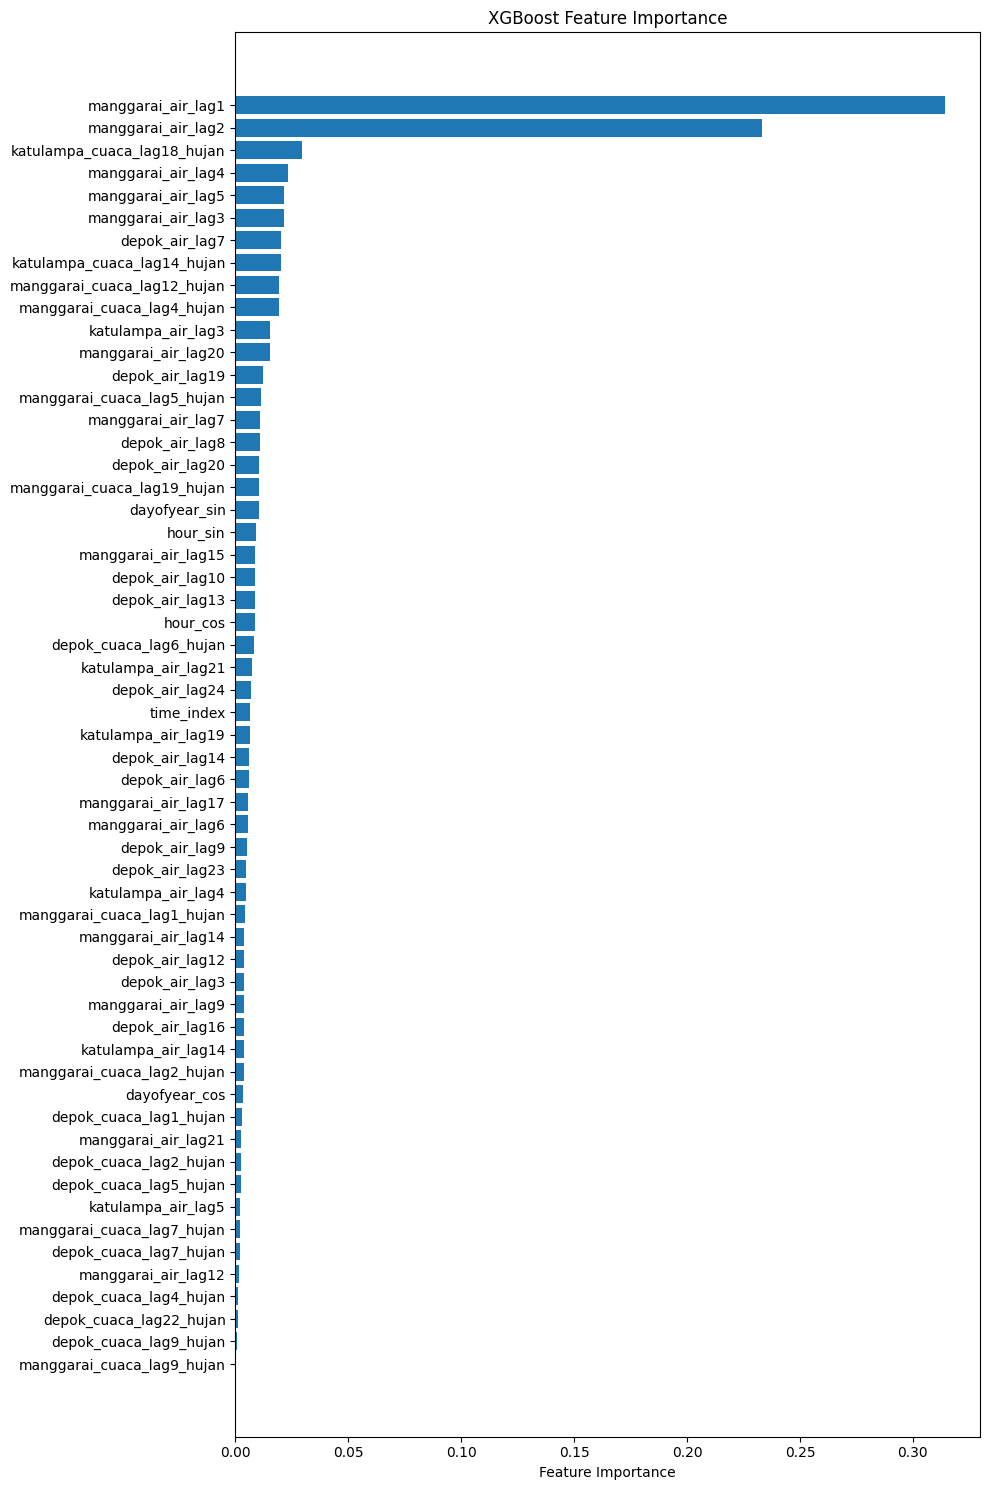

In [9]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nMost Important Features:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 15))
top_features = feature_importance
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

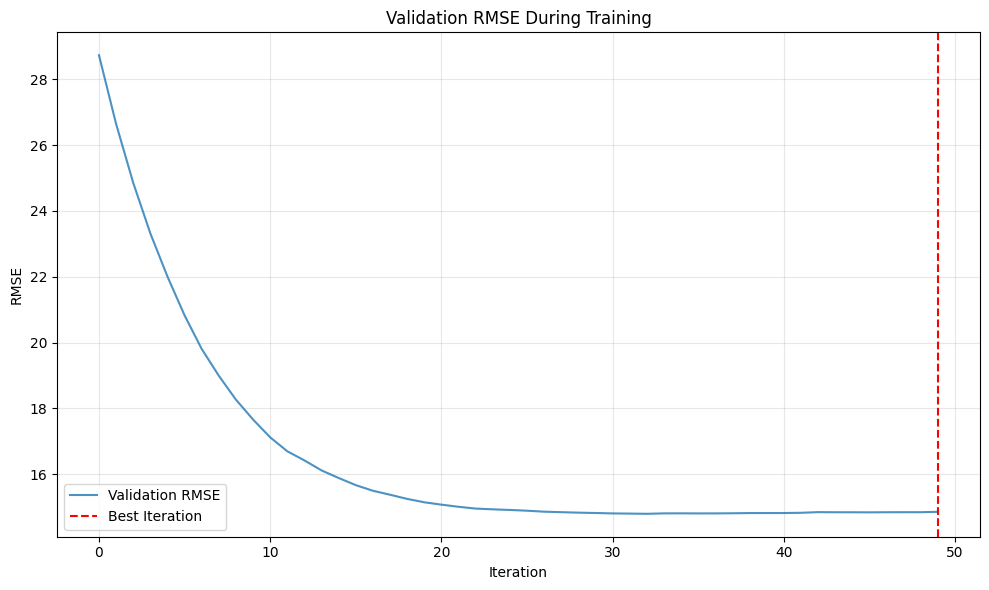

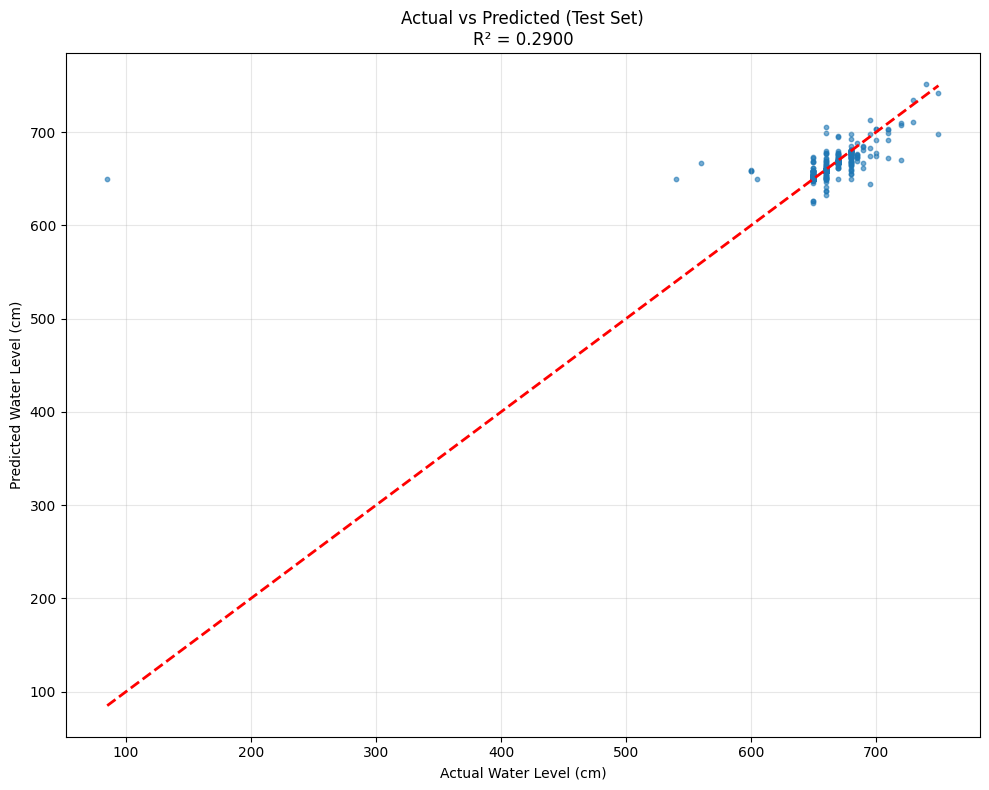

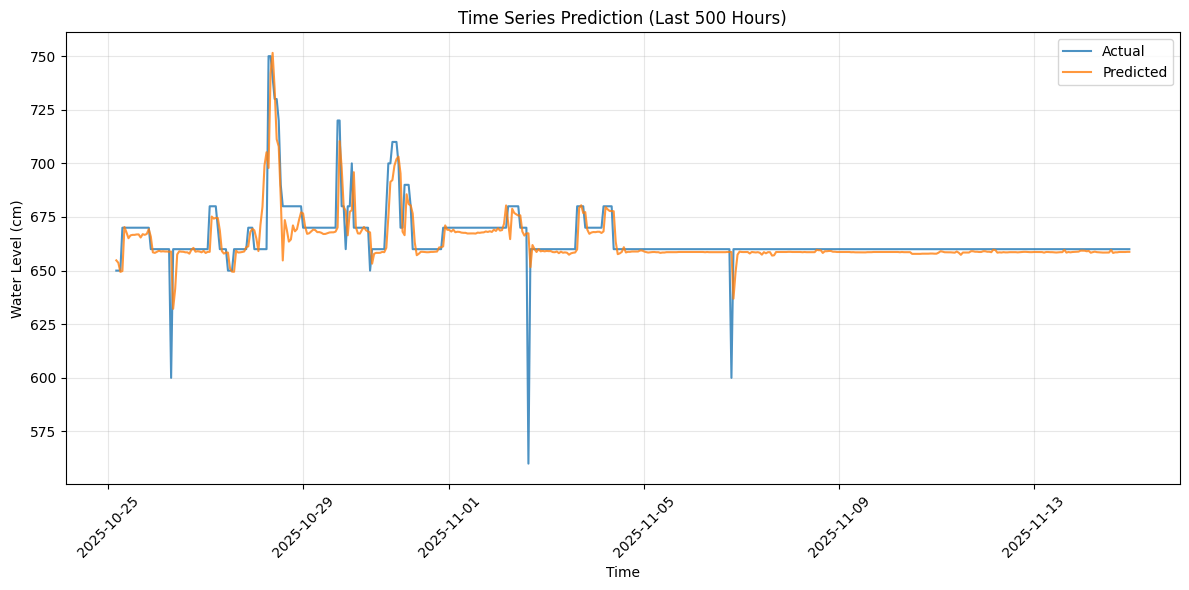

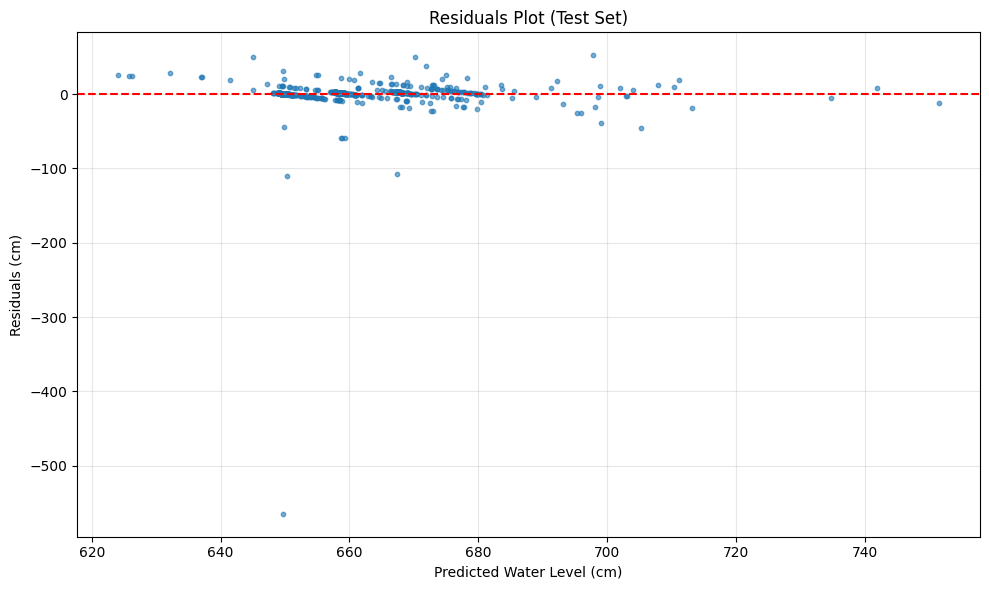

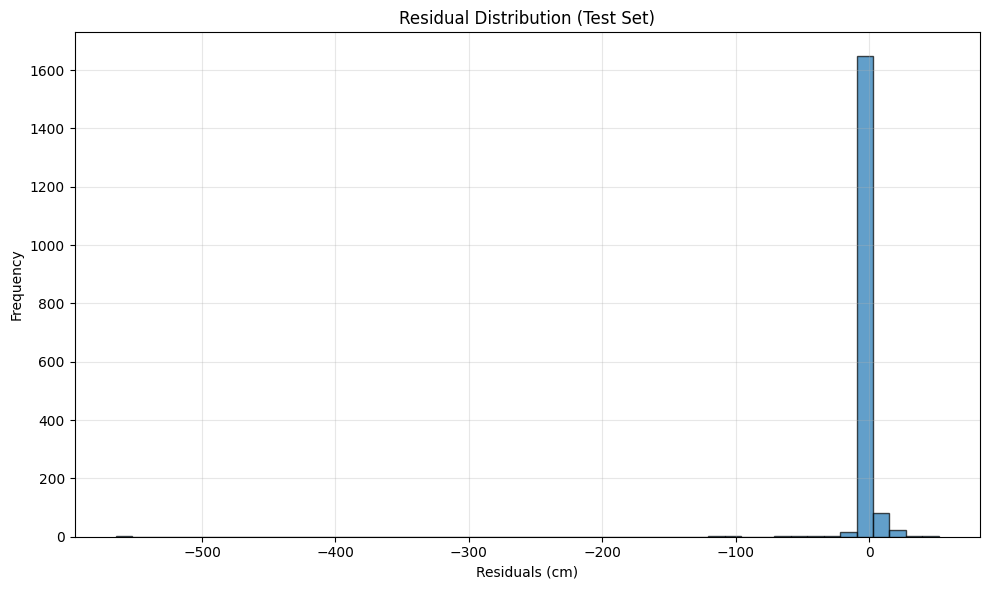

In [10]:
# --- PLOT 1: Training Validation Curve ---
plt.figure(figsize=(10, 6))
eval_results = model.evals_result()
if 'validation_0' in eval_results:
    plt.plot(eval_results['validation_0']['rmse'], label='Validation RMSE', alpha=0.8)
    # XGBoost best_iteration hanya tersedia jika early_stopping_rounds diaktifkan
    # Jika tidak, kita ambil iterasi terakhir
    best_iter = model.best_iteration if hasattr(model, 'best_iteration') else final_params['n_estimators'] - 1
    
    plt.axvline(x=best_iter, color='red', linestyle='--', label='Best Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('RMSE')
    plt.title('Validation RMSE During Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Training progress\nnot available',
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Training Progress')

plt.tight_layout()
plt.show()

# --- PLOT 2: Actual vs Predicted (Test Set) ---
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test_pred, alpha=0.6, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Water Level (cm)')
plt.ylabel('Predicted Water Level (cm)')
plt.title(f'Actual vs Predicted (Test Set)\nR² = {test_r2:.4f}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 3: Time Series Prediction (Last 500 Points) ---
plt.figure(figsize=(12, 6))
plot_points = min(500, len(y_test))
plt.plot(y_test.tail(plot_points), label='Actual', linewidth=1.5, alpha=0.8)
plt.plot(y_test.tail(plot_points).index, test_pred[-plot_points:],
         label='Predicted', linewidth=1.5, alpha=0.8)
plt.xlabel('Time')
plt.ylabel('Water Level (cm)')
plt.title(f'Time Series Prediction (Last {plot_points} Hours)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- PLOT 4: Residuals Plot ---
plt.figure(figsize=(10, 6))
plt.scatter(test_pred, residuals_test, alpha=0.6, s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Water Level (cm)')
plt.ylabel('Residuals (cm)')
plt.title('Residuals Plot (Test Set)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 5: Residuals Histogram ---
plt.figure(figsize=(10, 6))
plt.hist(residuals_test, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals (cm)')
plt.ylabel('Frequency')
plt.title('Residual Distribution (Test Set)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Best Model Visualization

In [5]:
model = xgb.XGBRegressor()
model.load_model('13_best_model.json')

     Tree  Node     ID             Feature  Split  Yes    No Missing  \
0       0     0    0-0  manggarai_air_lag1  635.0  0-1   0-2     0-2   
1       0     1    0-1  manggarai_air_lag1  595.0  0-3   0-4     0-4   
2       0     2    0-2  manggarai_air_lag1  694.0  0-5   0-6     0-6   
3       0     3    0-3  manggarai_air_lag4  575.0  0-7   0-8     0-8   
4       0     4    0-4  manggarai_air_lag1  615.0  0-9  0-10    0-10   
..    ...   ...    ...                 ...    ...  ...   ...     ...   
176     0   176  0-176                Leaf    NaN  NaN   NaN     NaN   
177     0   177  0-177                Leaf    NaN  NaN   NaN     NaN   
178     0   178  0-178                Leaf    NaN  NaN   NaN     NaN   
179     0   179  0-179                Leaf    NaN  NaN   NaN     NaN   
180     0   180  0-180                Leaf    NaN  NaN   NaN     NaN   

             Gain    Cover  Category  
0    2.866301e+07  27231.0       NaN  
1    3.658178e+06  14432.0       NaN  
2    7.356939e+06 

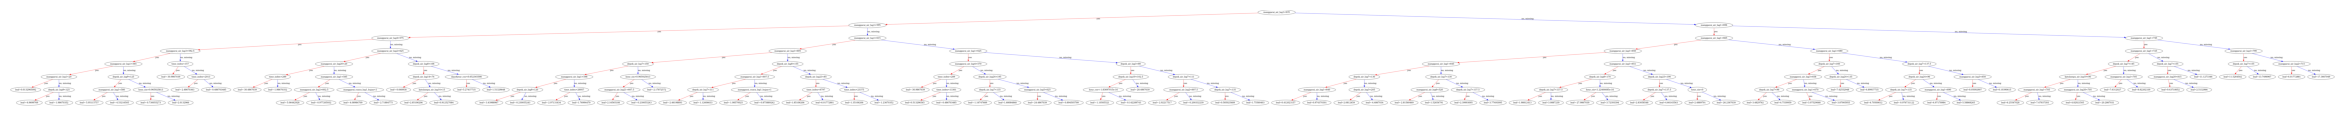

Sample: 2025-09-01 12:00:00
Actual: 670.0, Predicted: 667.2855224609375
Tanggal                      2025-09-01 12:00:00
time_index                          3.399600e+04
hour_sin                            1.224647e-16
hour_cos                           -1.000000e+00
dayofyear_sin                      -8.702939e-01
dayofyear_cos                      -4.925327e-01
manggarai_air_lag1                  6.700000e+02
manggarai_air_lag2                  6.700000e+02
manggarai_air_lag3                  6.700000e+02
manggarai_air_lag4                  6.800000e+02
manggarai_air_lag5                  6.700000e+02
manggarai_air_lag6                  6.700000e+02
manggarai_air_lag7                  6.700000e+02
manggarai_air_lag9                  6.700000e+02
manggarai_air_lag12                 6.700000e+02
manggarai_air_lag14                 6.700000e+02
manggarai_air_lag15                 6.800000e+02
manggarai_air_lag17                 6.800000e+02
manggarai_air_lag20                 7.000000e+

In [6]:
# 2a. Dump struktur pohon dalam bentuk DataFrame (numerik, mudah dianalisis)
booster = model.get_booster()
tree_df = booster.trees_to_dataframe()
tree_df.to_csv('14_tree_structure.csv', index=False)

# 2b. Ambil pohon ke-0 saja untuk dibahas di skripsi
tree_0 = tree_df[tree_df['Tree'] == 0]
print(tree_0)
tree_0.to_csv('14_tree_0.csv', index=False)

# 2c. Visualisasi pohon ke-0
fig, ax = plt.subplots(figsize=(30, 15))
xgb.plot_tree(booster, num_trees=0, ax=ax)
plt.savefig('14_tree_0_visualization.png', dpi=500, bbox_inches='tight')
plt.show()

# 2d. Ambil 1 observasi sampel untuk manual trace
sample_idx = 0  # bebas, nanti kita pilih yang menarik
sample_x = X_test.iloc[[sample_idx]]
sample_y_true = y_test.iloc[sample_idx]
sample_y_pred = model.predict(sample_x)[0]
print(f"Sample: {sample_x.index[0]}")
print(f"Actual: {sample_y_true}, Predicted: {sample_y_pred}")
print(sample_x.T)  # tampilkan nilai fitur untuk observasi ini

In [14]:
# Set to None to show all columns regardless of count
pd.set_option('display.max_columns', None)

# Optional: If the cell content itself is being truncated (e.g., long strings)
pd.set_option('display.max_colwidth', None)

print(sample_x, f"\n\nSample Y True", sample_y_true,f"\n\nSample Y Pred", sample_y_pred)

                     time_index      hour_sin  hour_cos  dayofyear_sin  \
Tanggal                                                                  
2025-09-01 12:00:00       33996  1.224647e-16      -1.0      -0.870294   

                     dayofyear_cos  manggarai_air_lag1  manggarai_air_lag2  \
Tanggal                                                                      
2025-09-01 12:00:00      -0.492533               670.0               670.0   

                     manggarai_air_lag3  manggarai_air_lag4  \
Tanggal                                                       
2025-09-01 12:00:00               670.0               680.0   

                     manggarai_air_lag5  manggarai_air_lag6  \
Tanggal                                                       
2025-09-01 12:00:00               670.0               670.0   

                     manggarai_air_lag7  manggarai_air_lag9  \
Tanggal                                                       
2025-09-01 12:00:00               67

In [7]:
# 3a. Buat explainer (TreeExplainer cepat untuk XGBoost)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
expected_value = explainer.expected_value
print(f"Expected value (base value): {expected_value}")

# 3b. Global importance: mean |SHAP|
mean_abs_shap = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
mean_abs_shap.to_csv('14_shap_global_importance.csv', index=False)
print(mean_abs_shap)

# 3c. Summary plot (beeswarm) — menunjukkan arah pengaruh fitur
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('14_shap_summary.png', dpi=200, bbox_inches='tight')
plt.close()

# 3d. Bar plot (rata-rata absolut SHAP)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.savefig('14_shap_bar.png', dpi=200, bbox_inches='tight')
plt.close()

# 3e. Local explanation: pilih observasi menarik
#     (misal: saat tinggi muka air paling tinggi di test set)
idx_extreme = np.argmax(y_test.values)
print(f"Extreme observation: {X_test.index[idx_extreme]}, actual={y_test.iloc[idx_extreme]}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx_extreme],
        base_values=expected_value,
        data=X_test.iloc[idx_extreme],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.savefig('14_shap_waterfall_extreme.png', dpi=200, bbox_inches='tight')
plt.close()

# 3f. Pilih juga 1 observasi "normal" untuk perbandingan
idx_normal = len(y_test) // 2
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx_normal],
        base_values=expected_value,
        data=X_test.iloc[idx_normal],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.savefig('14_shap_waterfall_normal.png', dpi=200, bbox_inches='tight')
plt.close()

Expected value (base value): 629.7465209960938
                        feature  mean_abs_shap
5            manggarai_air_lag1      12.220628
6            manggarai_air_lag2      10.512085
8            manggarai_air_lag4       1.336492
0                    time_index       0.833230
21               depok_air_lag7       0.785968
20               depok_air_lag6       0.703746
22               depok_air_lag8       0.633143
7            manggarai_air_lag3       0.399290
39   manggarai_cuaca_lag1_hujan       0.371899
23               depok_air_lag9       0.325462
17          manggarai_air_lag20       0.312438
9            manggarai_air_lag5       0.300926
3                 dayofyear_sin       0.272725
15          manggarai_air_lag15       0.220360
16          manggarai_air_lag17       0.205530
34           katulampa_air_lag4       0.203592
11           manggarai_air_lag7       0.194534
1                      hour_sin       0.190296
33           katulampa_air_lag3       0.160023
25           